In [1]:
import aiohttp
import asyncio
import json
import time
from tqdm import tqdm
from urllib.parse import quote
from bs4 import BeautifulSoup
import re
import os

In [ ]:
BASE_API = "https://marvel.fandom.com/api.php"
BASE_HTML = "https://marvel.fandom.com/wiki/"
HEADERS = {"User-Agent": "MarvelAsyncCrawler/1.0"}

WORKERS = 400            
RETRIES = 3            
SAVE_EVERY = 2000    
OUTPUT_FILE = "marvel_raw.json"

In [3]:
def normalize_slug(title):
    slug = re.sub(r"[^\w\-]", "", title.replace(" ", "_"))
    return slug.lower()

In [7]:
def get_all_marvel_titles_fast():
    import requests
    
    titles = []
    apcontinue = None
    
    while True:
        params = {
            "action": "query",
            "format": "json",
            "generator": "allpages",
            "gaplimit": "max",
            "gapnamespace": "0",
        }
        if apcontinue:
            params["gapcontinue"] = apcontinue
        
        r = requests.get(BASE_API, params=params, headers=HEADERS)
        data = r.json()
        
        pages = data.get("query", {}).get("pages", {})
        for _, p in pages.items():
            titles.append(p["title"])
        
        if "continue" in data:
            apcontinue = data["continue"]["gapcontinue"]
        else:
            break
    
    return titles

In [9]:
titles = get_all_marvel_titles_fast()
len(titles)

351984

In [ ]:
import aiohttp
import asyncio
import json
import time
import os
from urllib.parse import quote
from tqdm import tqdm
from aiolimiter import AsyncLimiter
import nest_asyncio

nest_asyncio.apply()


BASE_API = "https://marvel.fandom.com/api.php"
BASE_HTML = "https://marvel.fandom.com/wiki/"
HEADERS = {"User-Agent": "MarvelAsyncCrawler/1.0"}

WORKERS = 50              
RETRIES = 3              
RPS = 20                 
SAVE_EVERY = 20000        
OUTPUT_PREFIX = "marvel_raw_part"

limiter = AsyncLimiter(RPS, 1.0)


Всего заголовков: 351985


Скачивание Marvel:   3%|▎         | 9124/351985 [15:13<8:02:15, 11.85page/s] 

In [ ]:
def get_all_marvel_titles_fast():
    import requests
    
    titles = []
    apcontinue = None

    while True:
        params = {
            "action": "query",
            "format": "json",
            "generator": "allpages",
            "gaplimit": "max",
            "gapnamespace": "0",
        }
        if apcontinue:
            params["gapcontinue"] = apcontinue

        r = requests.get(BASE_API, params=params, headers=HEADERS)
        data = r.json()

        pages = data.get("query", {}).get("pages", {})
        for _, p in pages.items():
            titles.append(p["title"])

        if "continue" in data:
            apcontinue = data["continue"]["gapcontinue"]
        else:
            break

    return titles


titles = get_all_marvel_titles_fast()
print("Всего заголовков:", len(titles))


In [ ]:
async def fetch_text(session, url, params=None):
    async with limiter:   
        for _ in range(RETRIES):
            try:
                async with session.get(url, params=params, headers=HEADERS, timeout=20) as r:
                    if r.status == 200:
                        return await r.text()
            except:
                await asyncio.sleep(1)
    return None


async def download_page(session, title):
    #  API
    params = {"action": "parse", "page": title, "format": "json"}
    api_response = await fetch_text(session, BASE_API, params=params)

    if api_response:
        try:
            data = json.loads(api_response)
            html = data["parse"]["text"]["*"]
            url = data["parse"]["canonicalurl"]
            return {"title": title, "url": url, "html": html}
        except:
            pass

   
    url = BASE_HTML + quote(title.replace(" ", "_"))
    html = await fetch_text(session, url)

    return {"title": title, "url": url, "html": html}


In [ ]:
async def worker(name, session, queue, results, pbar, batch_index):
    while True:
        title = await queue.get()
        if title is None:
            return
        
        try:
            page = await download_page(session, title)
            results.append(page)
        except:
            results.append({"title": title, "url": None, "html": None})

        if len(results) >= SAVE_EVERY:
            part_file = f"{OUTPUT_PREFIX}_{batch_index[0]}.json"
            with open(part_file, "w", encoding="utf-8") as f:
                json.dump(results, f, ensure_ascii=False, indent=2)
            
            print(f"\n💾 Сохранён блок: {part_file} ({len(results)} страниц)")
            results.clear()
            batch_index[0] += 1

        pbar.update(1)
        pbar.refresh()
        queue.task_done()


In [ ]:
async def download_all(titles):
    queue = asyncio.Queue()
    for t in titles:
        queue.put_nowait(t)

    results = []
    batch_index = [1]  
    pbar = tqdm(total=len(titles), desc="Скачивание Marvel", unit="page")

    async with aiohttp.ClientSession() as session:
        workers = [
            asyncio.create_task(worker(f"w{i}", session, queue, results, pbar, batch_index))
            for i in range(WORKERS)
        ]

        await queue.join()

        for _ in workers:
            queue.put_nowait(None)

        await asyncio.gather(*workers)

    if results:
        part_file = f"{OUTPUT_PREFIX}_{batch_index[0]}.json"
        with open(part_file, "w", encoding="utf-8") as f:
            json.dump(results, f, ensure_ascii=False, indent=2)
        print(f"\n💾 Сохранён финальный блок: {part_file}")

    pbar.close()

In [ ]:
start_time = time.time()

await download_all(titles)

end_time = time.time()
print(f"\n✨ Готово! Загрузка заняла {end_time / 60:.2f} минут.")
print("Файлы сохранены как marvel_raw_part_1.json, marvel_raw_part_2.json, ...")

In [2]:
!pip install nest_asyncio
import nest_asyncio
nest_asyncio.apply()

In [ ]:
import json
import re
from bs4 import BeautifulSoup
from langchain.text_splitter import RecursiveCharacterTextSplitter
from urllib.parse import unquote
from tqdm import tqdm


CHUNK_SIZE = 1850
CHUNK_OVERLAP = 320

TEXT_SPLITTER = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]
)


def normalize_slug(slug: str) -> str:
    slug = unquote(slug)
    slug = re.sub(r"#.*$", "", slug)
    slug = re.sub(r"[^\w\-]", "", slug)
    return slug.replace(" ", "_").lower()


def extract_text_and_links(html: str):
    soup = BeautifulSoup(html, "html.parser")
    
    content = soup.find("div", class_="mw-parser-output")
    if not content:
        return None, {}

    # Удаляем мусор
    for bad in content.find_all(["table", "figure", "div", "span"]):
        cls = bad.get("class", [])
        if cls and {"infobox", "navbox", "toc", "metadata", "portable-infobox"} & set(cls):
            bad.decompose()

    link_map = {}
    texts = []

    for elem in content.find_all(["p", "h2", "h3", "h4", "ul", "ol"]):
        try:
            t = elem.get_text(" ", strip=True)
            if t:
                texts.append(t)

            for a in elem.find_all("a", href=True):
                href = a.get("href", "")
                if "/wiki/" in href:
                    slug = href.split("/wiki/")[-1].split("#")[0]
                    slug_norm = normalize_slug(slug)
                    anchor = a.get_text(strip=True)
                    if anchor:
                        link_map[anchor] = slug_norm
        except:
            continue

    full_text = "\n\n".join(texts)
    return full_text, link_map


def extract_chunk_links(chunk_text: str, link_map: dict):
    found = set()
    for anchor, slug in link_map.items():
        if re.search(rf"\b{re.escape(anchor)}\b", chunk_text, re.IGNORECASE):
            found.add(slug)
    return list(found)


INPUT_FILE = "marvel_raw.json"
OUTPUT_FILE = "marvel_dataset.json"

with open(INPUT_FILE, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

dataset = []

print("\nОбработка HTML - текст - чанки...")
for item in tqdm(raw_data, desc="Обработка страниц"):
    title = item["title"]
    url = item["url"]
    html = item["html"]

    if not html:
        continue

    full_text, link_map = extract_text_and_links(html)
    if not full_text or len(full_text) < 50:
        continue

    chunks = TEXT_SPLITTER.split_text(full_text)

    document_id = normalize_slug(title)

    for idx, chunk_text in enumerate(chunks, start=1):
        outgoing = extract_chunk_links(chunk_text, link_map)

        dataset.append({
            "document_id": document_id,
            "chunk_id": idx,
            "title": title,
            "chunk_text": chunk_text,
            "outgoing_links": outgoing,
            "source": url,
            "comment": f"Всего чанков: {len(chunks)}"
        })


with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(dataset, f, ensure_ascii=False, indent=2)

print("\n✨ Готово!")
print(f"Всего документов: {len(set(d['document_id'] for d in dataset))}")
print(f"Всего чанков: {len(dataset)}")
print(f"Сохранено в файл: {OUTPUT_FILE}")

In [10]:
titles

['"Another Super Hero" (Earth-616)',
 '"Big Boy" T-Rider Rex',
 '"Casanova" Chris Sims',
 '"Dog" Logan',
 '"Goblins"',
 '"Hor-Mi-Ga"',
 '"Mad-Dog" Rassitano',
 '"Nicaraguan Hellfire"',
 '"Scar" Turpin (Earth-616)',
 '"Tablet of Destinies"',
 '"Three-Fingers" Eddie Envers',
 '"Thumper" Morgan',
 '"Thumper" Morgan (Earth-616)',
 '"Yo-Yo" Rodriguez',
 '"pocket" dimension',
 '$$ Maje$tic',
 '$ Cult',
 '$ Cult (Earth-616)',
 '$kullocracy',
 "'67 Mysterio",
 "'Breed",
 "'Breed II Vol 1",
 "'Breed II Vol 1 1",
 "'Breed II Vol 1 2",
 "'Breed II Vol 1 3",
 "'Breed II Vol 1 4",
 "'Breed II Vol 1 5",
 "'Breed II Vol 1 6",
 "'Breed Vol 1",
 "'Breed Vol 1 1",
 "'Breed Vol 1 2",
 "'Breed Vol 1 3",
 "'Breed Vol 1 4",
 "'Breed Vol 1 5",
 "'Breed Vol 1 6",
 "'Bu Tones",
 "'Field-Grapples",
 "'Lectron",
 "'Lectron (Earth-12772)",
 "'Lectron (Earth-9602)",
 "'Maxwell Stockbridge'",
 "'Nam Magazine Vol 1",
 "'Nam Magazine Vol 1 1",
 "'Nam Magazine Vol 1 10",
 "'Nam Magazine Vol 1 2",
 "'Nam Magazine Vol 1

In [ ]:
async def fetch_text(session, url, params=None):
    for _ in range(RETRIES):
        try:
            async with session.get(url, params=params, headers=HEADERS, timeout=20) as r:
                if r.status == 200:
                    return await r.text()
        except:
            await asyncio.sleep(1)
    return None

In [ ]:
async def download_page(session, title):
    # API 
    params = {"action": "parse", "page": title, "format": "json"}
    api_response = await fetch_text(session, BASE_API, params=params)
    
    if api_response:
        try:
            data = json.loads(api_response)
            html = data["parse"]["text"]["*"]
            url = data["parse"]["canonicalurl"]
            return {"title": title, "url": url, "html": html}
        except:
            pass
    
    url = BASE_HTML + quote(title.replace(" ", "_"))
    html = await fetch_text(session, url)
    
    return {"title": title, "url": url, "html": html}

In [ ]:
async def worker(name, session, queue, results, pbar):
    while True:
        title = await queue.get()
        if title is None:
            return
        
        try:
            page = await download_page(session, title)
            results.append(page)
        except:
            results.append({"title": title, "url": None, "html": None})
        
        pbar.update(1)
        queue.task_done()

In [ ]:
async def download_all(titles):
    queue = asyncio.Queue()
    
    for t in titles:
        queue.put_nowait(t)
    
    results = []
    pbar = tqdm(total=len(titles), desc="Загрузка Marvel", unit="page")

    async with aiohttp.ClientSession() as session:
        workers = [
            asyncio.create_task(worker(f"w{i}", session, queue, results, pbar))
            for i in range(WORKERS)
        ]

        await queue.join()

        for _ in workers:
            queue.put_nowait(None)

        await asyncio.gather(*workers)

    pbar.close()
    return results

In [ ]:
start_time = time.time()

results = asyncio.run(download_all(titles))

end_time = time.time()
print(f"Готово! Загрузка заняла {end_time - start_time:.2f} сек.")

In [ ]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("Сохранено в", OUTPUT_FILE)

In [ ]:
import json
import re
from bs4 import BeautifulSoup
from urllib.parse import unquote
from tqdm import tqdm
from langchain.text_splitter import RecursiveCharacterTextSplitter
import pandas as pd
import glob
import os


BASE_DIR = ""
RAW_PATTERN = os.path.join(BASE_DIR, "marvel_raw_part_*.json")

FINAL_DIR = os.path.join(BASE_DIR, "final_dataset")
os.makedirs(FINAL_DIR, exist_ok=True)


CHUNK_SIZE = 1850
CHUNK_OVERLAP = 320

TEXT_SPLITTER = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP,
    separators=["\n\n", "\n", ". ", " ", ""]
)


def normalize_slug(slug: str) -> str:
    slug = unquote(slug)
    slug = re.sub(r"#.*$", "", slug)
    slug = re.sub(r"[^\w\-]", "", slug)
    return slug.replace(" ", "_").lower()


def extract_text_and_links(html: str):
    soup = BeautifulSoup(html, "html.parser")
    
    content = soup.find("div", class_="mw-parser-output")
    if not content:
        return None, {}

    for bad in content.find_all(["table", "div", "span", "figure"]):
        cls = bad.get("class", [])
        if cls and {"infobox", "navbox", "toc", "metadata", "portable-infobox"} & set(cls):
            bad.decompose()

    link_map = {}
    blocks = []

    for elem in content.find_all(["p", "h2", "h3", "h4", "ul", "ol"]):
        try:
            t = elem.get_text(" ", strip=True)
            if t:
                blocks.append(t)

            for a in elem.find_all("a", href=True):
                href = a.get("href", "")
                if "/wiki/" in href:
                    slug = href.split("/wiki/")[-1].split("#")[0]
                    anchor = a.get_text(strip=True)
                    if anchor:
                        link_map[anchor] = normalize_slug(slug)
        except:
            continue

    text = "\n\n".join(blocks)
    return text, link_map

def extract_chunk_links(chunk_text, link_map):
    found = set()
    for anchor, slug in link_map.items():
        if re.search(rf"\b{re.escape(anchor)}\b", chunk_text, re.IGNORECASE):
            found.add(slug)
    return list(found)



def process_raw_file(path, part_index):
    print(f"\n🔄 Обработка файла: {path}")

    with open(path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    dataset = []

    for item in tqdm(raw, desc=f"HTML → TEXT → CHUNKS (part {part_index})"):
        title = item["title"]
        url = item["url"]
        html = item["html"]

        if not html:
            continue

        text, link_map = extract_text_and_links(html)
        if not text or len(text) < 50:
            continue

        chunks = TEXT_SPLITTER.split_text(text)
        document_id = normalize_slug(title)

        for idx, chunk in enumerate(chunks, start=1):
            outgoing = extract_chunk_links(chunk, link_map)

            dataset.append({
                "document_id": document_id,
                "chunk_id": idx,
                "title": title,
                "chunk_text": chunk,
                "outgoing_links": outgoing,
                "source": url,
                "comment": f"Всего чанков: {len(chunks)}"
            })

   
    out_path = os.path.join(FINAL_DIR, f"marvel_dataset_part_{part_index}.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)

    print(f"✅ Готово: {out_path} — чанков {len(dataset)}")

    return out_path



raw_files = sorted(glob.glob(RAW_PATTERN))

processed_parts = []
for i, file in enumerate(raw_files, start=1):
    out = process_raw_file(file, i)
    processed_parts.append(out)

print("\nВсе части обработаны!")



print("\n🔗 Объединяю части...")

final_dataset = []

for part in processed_parts:
    with open(part, "r", encoding="utf-8") as f:
        data = json.load(f)
        final_dataset.extend(data)

final_json_path = os.path.join(FINAL_DIR, "marvel_dataset.json")

with open(final_json_path, "w", encoding="utf-8") as f:
    json.dump(final_dataset, f, ensure_ascii=False, indent=2)

print(f"📦 Итоговый JSON сохранён: {final_json_path}")
print(f"Всего чанков: {len(final_dataset)}")



print("\n📊 Создаю Excel…")

df = pd.DataFrame(final_dataset)
excel_path = os.path.join(FINAL_DIR, "marvel_dataset.xlsx")
df.to_excel(excel_path, index=False)

print(f"✨ Excel сохранён: {excel_path}")
print("Готово!")


🔄 Обработка файла: /home/timofey/work/ITMO/marvel_raw_part_1.json


In [ ]:
import json
import re
from collections import Counter
from pathlib import Path
from tqdm import tqdm


BASE_DIR = Path("/home/timofey/work/ITMO/final_dataset")
INPUT_PATH = BASE_DIR / "marvel_dataset.jsonl"
OUTPUT_PATH = BASE_DIR / "marvel_dataset_clean.jsonl"

print(f"Входной файл: {INPUT_PATH}")
print(f"Выходной файл: {OUTPUT_PATH}")


SECTION_LINES = {
    "name",
    "current alias",
    "aliases",
    "affiliation and relationships",
    "group affiliation",
    "marital status",
    "physical characteristics",
    "gender",
    "eyes",
    "irises:",
    "hair",
    "origin and living status",
    "origin",
    "living status",
    "reality",
    "personal information",
    "identity",
    "citizenship",
    "occupation",
    "base of operations",
    "creators and appearances",
    "creators",
    "first",
    "last",
    "history",
    "see also",
    "links and references",
    "references",
    "notes",
    "external links",
    "publication details",
    "comic volume(s)",
    "issues/episodes",
    "gallery",
    "synopsis",
}


NOISY_LINE_PATTERNS = [
    r"\d+\s+appearance\(s\).*",
    r"\d+\s+image\(s\).*",
    r"\d+\s+quotation\(s\).*",
    r"\d+\s+mention\(s\).*",
]


LINK_PREFIXES_TO_DROP = [
    "category",
    "categoryweek_",
    "character_index",
    "template",
    "user_",
    "talk_",
    "blog_",
    "forum_",
    "help_",
]

MIN_CHARS = 200
MIN_WORDS = 25



def is_gallery_doc(rec) -> bool:
    title = (rec.get("title") or "").lower()
    doc_id = (rec.get("document_id") or "").lower()
    if "gallery" in title or "gallery" in doc_id:
        return True
    return False

def is_category_doc(rec) -> bool:
    title = rec.get("title") or ""
    doc_id = rec.get("document_id") or ""
    return title.startswith("Category:") or doc_id.lower().startswith("category")

def clean_outgoing_links(links):
    cleaned = []
    for slug in links or []:
        s = slug.lower()
        # отбрасываем мусорные префиксы
        if any(s.startswith(p) for p in LINK_PREFIXES_TO_DROP):
            continue
        # галереи
        if s.endswith("gallery"):
            continue
        cleaned.append(slug)
    # дедуп
    return sorted(set(cleaned))

def clean_chunk_text(text: str) -> str:
    if not text:
        return ""
    text = re.sub(r"\[\s*\d+\s*\]", "", text)
    text = re.sub(r"\[\s*\]", "", text)
    lines = text.splitlines()
    new_lines = []
    seen_lines = set()

    for line in lines:
        raw = line
        line = line.strip()

        if not line:
            continue

        lower = line.lower()
        if lower in SECTION_LINES:
            continue
        noisy = False
        for pat in NOISY_LINE_PATTERNS:
            if re.match(pat, lower):
                noisy = True
                break
        if noisy:
            continue
        if len(line) <= 3 and " " not in line:
            continue


        if line in seen_lines:
            continue
        seen_lines.add(line)

        new_lines.append(line)


    if not new_lines:
        return ""

    cleaned = "\n\n".join(new_lines)


    cleaned = re.sub(r"[ \t]+", " ", cleaned)

    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned)

    return cleaned.strip()



stats = Counter()
raw_doc_ids = set()
clean_doc_ids = set()

total_raw_len = 0
total_clean_len = 0

print("\nНачинаем проход по датасету...")

with INPUT_PATH.open("r", encoding="utf-8") as fin, OUTPUT_PATH.open("w", encoding="utf-8") as fout:
    for line in tqdm(fin, desc="Обработка чанков"):
        line = line.strip()
        if not line:
            continue

        stats["lines_read"] += 1

        try:
            rec = json.loads(line)
        except Exception:
            stats["parse_error"] += 1
            continue

        stats["chunks_raw"] += 1
        doc_id = rec.get("document_id")
        raw_doc_ids.add(doc_id)

        raw_text = rec.get("chunk_text") or ""
        total_raw_len += len(raw_text)

        title = rec.get("title") or ""

        
        if is_gallery_doc(rec):
            stats["dropped_gallery_doc"] += 1
            continue

      
        if is_category_doc(rec):
            stats["dropped_category_doc"] += 1
            continue

    
        cleaned_text = clean_chunk_text(raw_text)

        wc = len(cleaned_text.split())
        if not cleaned_text or len(cleaned_text) < MIN_CHARS or wc < MIN_WORDS:
            stats["dropped_too_short"] += 1
            continue


        links = rec.get("outgoing_links", [])
        cleaned_links = clean_outgoing_links(links)

        if not cleaned_links:
            stats["no_links_after_clean"] += 1


        new_rec = dict(rec)
        new_rec["chunk_text"] = cleaned_text
        new_rec["outgoing_links"] = cleaned_links

        fout.write(json.dumps(new_rec, ensure_ascii=False) + "\n")

        stats["chunks_kept"] += 1
        clean_doc_ids.add(doc_id)
        total_clean_len += len(cleaned_text)

print("\n✅ Очистка завершена.\n")


print("===== СТАТИСТИКА ДО ОЧИСТКИ =====")
print(f"Всего строк (jsonl):     {stats['lines_read']}")
print(f"Успешно распарсено:      {stats['chunks_raw']}")
print(f"Ошибок парсинга JSON:    {stats['parse_error']}")
print(f"Уникальных документов:   {len(raw_doc_ids)}")
if stats["chunks_raw"]:
    avg_raw_len = total_raw_len / stats["chunks_raw"]
    print(f"Средняя длина чанка:     {avg_raw_len:.1f} символов")

print("\n===== СТАТИСТИКА ПОСЛЕ ОЧИСТКИ =====")
print(f"Сохранено чанков:        {stats['chunks_kept']}")
print(f"Уникальных документов:   {len(clean_doc_ids)}")
if stats["chunks_kept"]:
    avg_clean_len = total_clean_len / stats["chunks_kept"]
    print(f"Средняя длина чанка:     {avg_clean_len:.1f} символов")

print("\n===== СКОЛЬКО И ЧТО МЫ ВЫКИНУЛИ =====")
print(f"Галерейные страницы:     {stats['dropped_gallery_doc']}")
print(f"Категории:               {stats['dropped_category_doc']}")
print(f"Слишком короткие чанки:  {stats['dropped_too_short']}")
print(f"Чанков без ссылок (после очистки outgoing_links): {stats['no_links_after_clean']}")
print(f"Ошибки парсинга JSON:    {stats['parse_error']}")

total_dropped = (
    stats["dropped_gallery_doc"]
    + stats["dropped_category_doc"]
    + stats["dropped_too_short"]
)
print(f"\nВсего чанков до очистки: {stats['chunks_raw']}")
print(f"Всего выкинули:          {total_dropped}")
if stats["chunks_raw"]:
    print(f"Доля выкинутых:          {100.0 * total_dropped / stats['chunks_raw']:.2f}%")

print(f"\n🎉 Готово! Очищенный датасет: {OUTPUT_PATH}")


Входной файл: /home/timofey/work/ITMO/final_dataset/marvel_dataset.jsonl
Выходной файл: /home/timofey/work/ITMO/final_dataset/marvel_dataset_clean.jsonl

🔍 Начинаем проход по датасету...


Обработка чанков: 0it [00:00, ?it/s]

Обработка чанков: 369295it [00:32, 11327.74it/s]



✅ Очистка завершена.

===== СТАТИСТИКА ДО ОЧИСТКИ =====
Всего строк (jsonl):     369295
Успешно распарсено:      369295
Ошибок парсинга JSON:    0
Уникальных документов:   145348
Средняя длина чанка:     1280.7 символов

===== СТАТИСТИКА ПОСЛЕ ОЧИСТКИ =====
Сохранено чанков:        346517
Уникальных документов:   129483
Средняя длина чанка:     1209.9 символов

===== СКОЛЬКО И ЧТО МЫ ВЫКИНУЛИ =====
Галерейные страницы:     9370
Категории:               0
Слишком короткие чанки:  13408
Чанков без ссылок (после очистки outgoing_links): 3880
Ошибки парсинга JSON:    0

Всего чанков до очистки: 369295
Всего выкинули:          22778
Доля выкинутых:          6.17%

🎉 Готово! Очищенный датасет: /home/timofey/work/ITMO/final_dataset/marvel_dataset_clean.jsonl


In [ ]:
import json
import re
from collections import Counter
from pathlib import Path
from tqdm import tqdm

BASE_DIR = Path("")
INPUT_PATH = BASE_DIR / "marvel_dataset_clean.jsonl"  
OUTPUT_PATH = BASE_DIR / "marvel_dataset_final.jsonl"  

print(f"Вход:  {INPUT_PATH}")
print(f"Выход: {OUTPUT_PATH}")



NOISY_PREFIXES = [
    "races and species:",
    "realities:",
    "locations:",
    "synopsis for",
    "appearing in",
    "featured characters:",
    "supporting characters:",
    "antagonists:",
    "other characters:",
    "issue details",
    "alternate covers",
    "marvel unlimited",
    "release date",
    "cover date",
    "editor-in-chief",
    "writer(s)",
    "penciler(s)",
    "inker(s)",
    "colorist(s)",
    "letterer(s)",
    "editor(s)",
    "work history",
]


MIN_CHARS_SECOND = 120
MIN_WORDS_SECOND = 15

def extra_clean_text(text: str) -> str:
    """
    Дополнительная очистка уже более-менее чистого текста:
    - убираем строки-числа (типа 1860)
    - убираем шапки / служебные строки по префиксам
    - убираем дубликаты строк
    """
    if not text:
        return ""

    lines = text.splitlines()
    new_lines = []
    seen = set()

    for raw in lines:
        line = raw.strip()
        if not line:
            continue

        lower = line.lower()

        
        if re.fullmatch(r"\d{3,4}", line):
            continue

      
        if any(lower.startswith(pref) for pref in NOISY_PREFIXES):
            continue

       
        if line in seen:
            continue
        seen.add(line)

        new_lines.append(line)

    if not new_lines:
        return ""

    cleaned = "\n\n".join(new_lines)

    
    cleaned = re.sub(r"[ \t]+", " ", cleaned)
    cleaned = re.sub(r"\n{3,}", "\n\n", cleaned)

    return cleaned.strip()



stats = Counter()
doc_ids_in = set()
doc_ids_out = set()

total_len_in = 0
total_len_out = 0

print("\nВторой проход по очищенному датасету...")

with INPUT_PATH.open("r", encoding="utf-8") as fin, OUTPUT_PATH.open("w", encoding="utf-8") as fout:
    for line in tqdm(fin, desc="Доп. обработка чанков"):
        line = line.strip()
        if not line:
            continue

        stats["lines_read"] += 1

        try:
            rec = json.loads(line)
        except Exception:
            stats["parse_error"] += 1
            continue

        stats["chunks_in"] += 1

        doc_id = rec.get("document_id")
        doc_ids_in.add(doc_id)

        text = rec.get("chunk_text") or ""
        total_len_in += len(text)
        links = rec.get("outgoing_links", []) or []

   
        cleaned_text = extra_clean_text(text)
        wc = len(cleaned_text.split())

      
        if not cleaned_text:
            stats["dropped_empty_after_extra_clean"] += 1
            continue


        too_short = (len(cleaned_text) < MIN_CHARS_SECOND or wc < MIN_WORDS_SECOND)

        
        if too_short and not links:
            stats["dropped_short_no_links"] += 1
            continue


        rec["chunk_text"] = cleaned_text

        fout.write(json.dumps(rec, ensure_ascii=False) + "\n")

        stats["chunks_out"] += 1
        doc_ids_out.add(doc_id)
        total_len_out += len(cleaned_text)

print("\n Доп. очистка завершена.\n")

print("===== ВХОДНОЙ ФАЙЛ (после 1-го прохода) =====")
print(f"Строк всего (jsonl):       {stats['lines_read']}")
print(f"Чанков считано:            {stats['chunks_in']}")
print(f"Уникальных документов:     {len(doc_ids_in)}")
if stats["chunks_in"]:
    print(f"Средняя длина чанка:       {total_len_in / stats['chunks_in']:.1f} символов")

print("\n===== ВЫХОДНОЙ ФАЙЛ (после 2-го прохода) =====")
print(f"Чанков сохранено:          {stats['chunks_out']}")
print(f"Уникальных документов:     {len(doc_ids_out)}")
if stats["chunks_out"]:
    print(f"Средняя длина чанка:       {total_len_out / stats['chunks_out']:.1f} символов")

print("\n===== ЧТО ВЫКИНУЛИ НА 2-М ПРОХОДЕ =====")
print(f"Пустых после extra_clean:  {stats['dropped_empty_after_extra_clean']}")
print(f"Коротких без ссылок:       {stats['dropped_short_no_links']}")
print(f"Ошибок парсинга JSON:      {stats['parse_error']}")

total_dropped_2 = stats["dropped_empty_after_extra_clean"] + stats["dropped_short_no_links"]
print(f"\nВсего чанков на входе:     {stats['chunks_in']}")
print(f"Всего выкинуто на 2-м проходе: {total_dropped_2}")
if stats["chunks_in"]:
    print(f"Доля выкинутых (2-й проход): {100.0 * total_dropped_2 / stats['chunks_in']:.2f}%")

print(f"\n🎉 FINAL DATASET SAVED → {OUTPUT_PATH}")

Вход:  /home/timofey/work/ITMO/final_dataset/marvel_dataset_clean.jsonl
Выход: /home/timofey/work/ITMO/final_dataset/marvel_dataset_final.jsonl

🔍 Второй проход по очищенному датасету...


Доп. обработка чанков: 346517it [00:25, 13553.10it/s]


✅ Доп. очистка завершена.

===== ВХОДНОЙ ФАЙЛ (после 1-го прохода) =====
Строк всего (jsonl):       346517
Чанков считано:            346517
Уникальных документов:     129483
Средняя длина чанка:       1209.9 символов

===== ВЫХОДНОЙ ФАЙЛ (после 2-го прохода) =====
Чанков сохранено:          346490
Уникальных документов:     129483
Средняя длина чанка:       1169.3 символов

===== ЧТО ВЫКИНУЛИ НА 2-М ПРОХОДЕ =====
Пустых после extra_clean:  4
Коротких без ссылок:       23
Ошибок парсинга JSON:      0

Всего чанков на входе:     346517
Всего выкинуто на 2-м проходе: 27
Доля выкинутых (2-й проход): 0.01%

🎉 FINAL DATASET SAVED → /home/timofey/work/ITMO/final_dataset/marvel_dataset_final.jsonl


Читаем файл: /home/timofey/work/ITMO/final_dataset/marvel_dataset_final.jsonl


Чтение финального датасета: 346490it [00:04, 83339.18it/s]



===== ОБЩАЯ СТАТИСТИКА =====
Всего чанков:              346490
Всего уникальных документов: 129483
Среднее число чанков на документ: 2.68
Средняя длина чанка (символов):   1169.3
Медиана длины чанка (символов):    1300.0
Средняя длина чанка (слов):        187.4
Медиана длины чанка (слов):         204.0
Среднее число ссылок per chunk:    13.76
Доля чанков без ссылок:            1.11%

===== ТОП-10 ДОКУМЕНТОВ ПО ЧИСЛУ ЧАНКОВ =====


,document_id,title,chunks_count,example_source
0,earth-616expandedhistorypart3,Earth-616/Expanded History Part 3,275,https://marvel.fandom.com/wiki/Earth-616/Expan...
1,daleks,Daleks,267,https://marvel.fandom.com/wiki/Daleks
2,jameshowlettearth-616expandedhistory,James Howlett (Earth-616)/Expanded History,261,https://marvel.fandom.com/wiki/James_Howlett_%...
3,jameshowlettearth616expandedhistory,James Howlett (Earth 616)/Expanded History,261,https://marvel.fandom.com/wiki/James_Howlett_%...
4,bobbanner,Bob Banner,229,https://marvel.fandom.com/wiki/Bob_Banner
5,bobdanner,Bob Danner,229,https://marvel.fandom.com/wiki/Bob_Danner
6,brucebancroft,Bruce Bancroft,229,https://marvel.fandom.com/wiki/Bruce_Bancroft
7,brucebannerearth-616,Bruce Banner (Earth-616),229,https://marvel.fandom.com/wiki/Bruce_Banner_%2...
8,brucebarnes,Bruce Barnes,229,https://marvel.fandom.com/wiki/Bruce_Barnes
9,brucebixby,Bruce Bixby,229,https://marvel.fandom.com/wiki/Bruce_Bixby


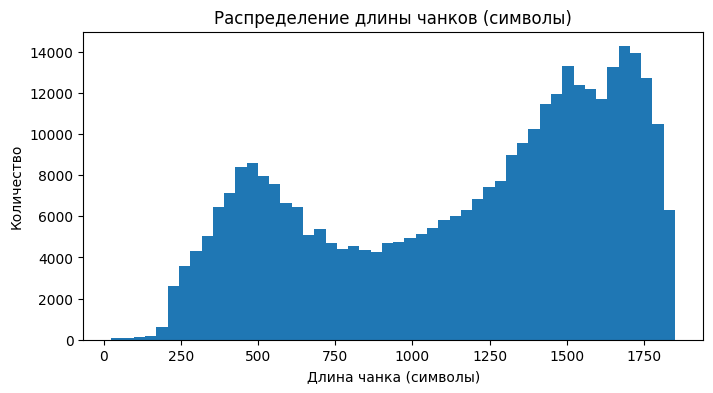

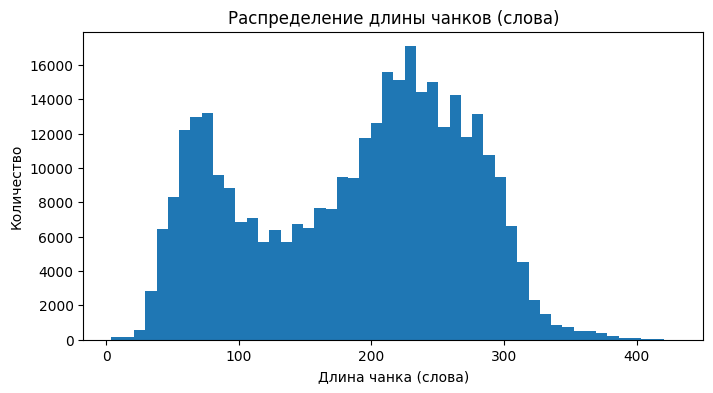

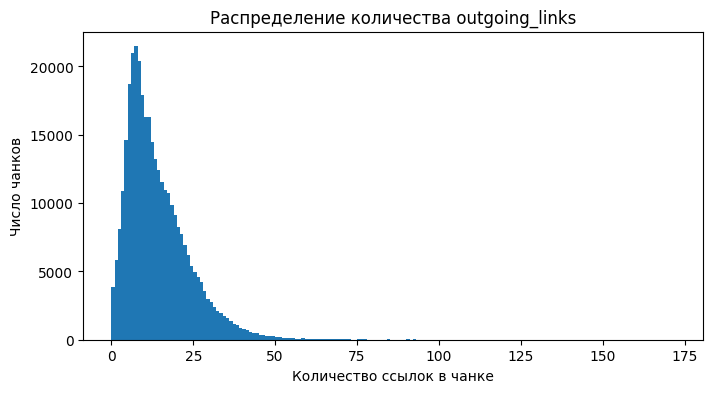


===== СЛУЧАЙНЫЙ СЭМПЛ 5 ЧАНКОВ =====


,document_id,chunk_id,title,len_chars,len_words,links_count,preview
0,bobdanner,188,Bob Danner,1749,304,20,. Homing Ability: The Hulk also has a seemingl...
1,cainmarkoearth-13264,7,Cain Marko (Earth-13264),1670,270,27,Davos (Earth-13264)\n\nAppearances: Age of Ult...
2,earth-17516,1,Earth-17516,775,131,15,MCU Earth destroyed Official Name Earth-17516 ...
3,emperorthakorr,7,Emperor Thakorr!,951,163,6,"There, Thakorr decided that it was time to get..."
4,fantasticfourvol3576,2,Fantastic Four Vol 3 576,1056,129,15,Ul-Uhar ⏵ (First appearance) Unnamed Chordai k...


In [ ]:
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm


BASE_DIR = Path("")
INPUT_PATH = BASE_DIR / "marvel_dataset_final.jsonl"

print(f"Читаем файл: {INPUT_PATH}")


chunk_lengths_chars = []
chunk_lengths_words = []
links_counts = []

doc_chunk_counts = Counter()
doc_titles = {}
doc_example_sources = {}

total_chunks = 0
total_links = 0

with INPUT_PATH.open("r", encoding="utf-8") as f:
    for line in tqdm(f, desc="Чтение финального датасета"):
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except Exception as e:
            print("Ошибка парсинга JSON:", e)
            continue

        total_chunks += 1

        doc_id = rec.get("document_id")
        title = rec.get("title") or ""
        text = rec.get("chunk_text") or ""
        links = rec.get("outgoing_links") or []
        source = rec.get("source") or ""

        
        chunk_lengths_chars.append(len(text))
        chunk_lengths_words.append(len(text.split()))
        links_counts.append(len(links))

        total_links += len(links)

        if doc_id is not None:
            doc_chunk_counts[doc_id] += 1
            if doc_id not in doc_titles:
                doc_titles[doc_id] = title
            if doc_id not in doc_example_sources:
                doc_example_sources[doc_id] = source

n_docs = len(doc_chunk_counts)
avg_chunks_per_doc = total_chunks / n_docs if n_docs else 0
avg_links_per_chunk = total_links / total_chunks if total_chunks else 0

print("\n===== ОБЩАЯ СТАТИСТИКА =====")
print(f"Всего чанков:              {total_chunks}")
print(f"Всего уникальных документов: {n_docs}")
print(f"Среднее число чанков на документ: {avg_chunks_per_doc:.2f}")
print(f"Средняя длина чанка (символов):   {np.mean(chunk_lengths_chars):.1f}")
print(f"Медиана длины чанка (символов):    {np.median(chunk_lengths_chars):.1f}")
print(f"Средняя длина чанка (слов):        {np.mean(chunk_lengths_words):.1f}")
print(f"Медиана длины чанка (слов):         {np.median(chunk_lengths_words):.1f}")
print(f"Среднее число ссылок per chunk:    {avg_links_per_chunk:.2f}")
print(f"Доля чанков без ссылок:            {np.mean(np.array(links_counts) == 0) * 100:.2f}%")

top_n = 10
top_docs = doc_chunk_counts.most_common(top_n)

rows = []
for doc_id, cnt in top_docs:
    rows.append({
        "document_id": doc_id,
        "title": doc_titles.get(doc_id, ""),
        "chunks_count": cnt,
        "example_source": doc_example_sources.get(doc_id, "")
    })

top_docs_df = pd.DataFrame(rows)
print("\n===== ТОП-10 ДОКУМЕНТОВ ПО ЧИСЛУ ЧАНКОВ =====")
display(top_docs_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(chunk_lengths_chars, bins=50)
ax.set_title("Распределение длины чанков (символы)")
ax.set_xlabel("Длина чанка (символы)")
ax.set_ylabel("Количество")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(chunk_lengths_words, bins=50)
ax.set_title("Распределение длины чанков (слова)")
ax.set_xlabel("Длина чанка (слова)")
ax.set_ylabel("Количество")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(links_counts, bins=range(0, max(links_counts)+2))
ax.set_title("Распределение количества outgoing_links")
ax.set_xlabel("Количество ссылок в чанке")
ax.set_ylabel("Число чанков")
plt.show()

sample_n = 5
print(f"\n===== СЛУЧАЙНЫЙ СЭМПЛ {sample_n} ЧАНКОВ =====")
sample_indices = np.random.choice(total_chunks, size=min(sample_n, total_chunks), replace=False)

sample_records = []
with INPUT_PATH.open("r", encoding="utf-8") as f:
    i = 0
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rec = json.loads(line)
        except:
            continue
        if i in sample_indices:
            sample_records.append({
                "document_id": rec.get("document_id"),
                "chunk_id": rec.get("chunk_id"),
                "title": rec.get("title"),
                "len_chars": len(rec.get("chunk_text") or ""),
                "len_words": len((rec.get("chunk_text") or "").split()),
                "links_count": len(rec.get("outgoing_links") or []),
                "preview": (rec.get("chunk_text") or "")[:300] + ("..." if len(rec.get("chunk_text") or "") > 300 else "")
            })
        i += 1

sample_df = pd.DataFrame(sample_records)
display(sample_df)